In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve
import xgboost as xgb
import lightgbm as lgb
import os

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)

print(f"pandas:    {pd.__version__}")
print(f"numpy:     {np.__version__}")
print(f"xgboost:   {xgb.__version__}")
print(f"lightgbm:  {lgb.__version__}")

pandas:    3.0.1
numpy:     2.4.3
xgboost:   3.2.0
lightgbm:  4.6.0


In [2]:
# Load clean train and test sets
# Gradient boosting does not require WoE encoding
# Uses df_train.pkl and df_test.pkl (cleaned, non-WoE)

df_train = pd.read_pickle("../data/processed/df_train.pkl")
df_test  = pd.read_pickle("../data/processed/df_test.pkl")

target = "default_flag"

# Use same 14 features selected in Notebook 04
# but in their original (non-WoE) form
# Drop grade and int_rate (redundant with sub_grade)
# Keep installment and revol_util — no multicollinearity concern for tree models

selected_raw_numeric = [
    "loan_amnt", "installment", "dti", "fico_range_low",
    "inq_last_6mths", "revol_util", "mort_acc",
    "mths_since_recent_inq", "log_annual_inc"
]

selected_raw_categorical = [
    "sub_grade", "term", "purpose",
    "verification_status", "home_ownership"
]

# Encode categoricals as category dtype for LightGBM
for col in selected_raw_categorical:
    df_train[col] = df_train[col].astype("category")
    df_test[col]  = df_test[col].astype("category")

feature_cols = selected_raw_numeric + selected_raw_categorical

X_train = df_train[feature_cols]
y_train = df_train[target].values

X_test  = df_test[feature_cols]
y_test  = df_test[target].values

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train default rate: {y_train.mean()*100:.2f}%")
print(f"y_test  default rate: {y_test.mean()*100:.2f}%")
print()
print(f"Numeric features:     {len(selected_raw_numeric)}")
print(f"Categorical features: {len(selected_raw_categorical)}")

X_train: (829355, 14)
X_test:  (518744, 14)
y_train default rate: 18.46%
y_test  default rate: 22.42%

Numeric features:     9
Categorical features: 5


## Objective

Train and evaluate gradient boosting challengers (XGBoost and LightGBM)
against the logistic regression champion from Notebook 05.

Key differences from logistic regression:
- No WoE encoding required — tree models handle non-linearity natively
- installment and revol_util reinstated — no multicollinearity concern
- Categorical features encoded as category dtype for LightGBM native handling
- Evaluation on identical train/test split for direct comparison

Base model (Logistic Regression):
  Test AUROC: 0.7042  |  Test Gini: 0.4084  |  Test KS: 0.2946

In [3]:
# LightGBM — baseline fit with sensible defaults
# No hyperparameter tuning yet — establish baseline first

lgb_params = {
    "objective"        : "binary",
    "metric"           : "auc",
    "learning_rate"    : 0.05,
    "num_leaves"       : 63,
    "max_depth"        : -1,
    "min_child_samples": 100,
    "subsample"        : 0.8,
    "colsample_bytree" : 0.8,
    "reg_alpha"        : 0.1,
    "reg_lambda"       : 1.0,
    "n_estimators"     : 1000,
    "random_state"     : 42,
    "verbose"          : -1,
}

lgb_model = lgb.LGBMClassifier(**lgb_params)

lgb_model.fit(
    X_train, y_train,
    eval_set              = [(X_test, y_test)],
    callbacks             = [
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=100)
    ]
)

lgb_train_probs = lgb_model.predict_proba(X_train)[:, 1]
lgb_test_probs  = lgb_model.predict_proba(X_test)[:, 1]

lgb_train_auroc = roc_auc_score(y_train, lgb_train_probs)
lgb_test_auroc  = roc_auc_score(y_test,  lgb_test_probs)
lgb_train_gini  = 2 * lgb_train_auroc - 1
lgb_test_gini   = 2 * lgb_test_auroc  - 1

fpr, tpr, _  = roc_curve(y_test, lgb_test_probs)
lgb_test_ks  = (tpr - fpr).max()

print(f"LightGBM Results:")
print(f"  Best iteration:  {lgb_model.best_iteration_}")
print(f"  Train AUROC:     {lgb_train_auroc:.4f}  Gini: {lgb_train_gini:.4f}")
print(f"  Test  AUROC:     {lgb_test_auroc:.4f}  Gini: {lgb_test_gini:.4f}")
print(f"  Test  KS:        {lgb_test_ks:.4f}")
print(f"  Gini drop:       {(lgb_train_gini - lgb_test_gini):.4f}")
print()
print(f"vs Logistic Regression champion:")
print(f"  Test Gini:       0.4084")
print(f"  Improvement:     {(lgb_test_gini - 0.4084):+.4f}")

[100]	valid_0's auc: 0.707916
[200]	valid_0's auc: 0.708632
LightGBM Results:
  Best iteration:  246
  Train AUROC:     0.7339  Gini: 0.4678
  Test  AUROC:     0.7087  Gini: 0.4174
  Test  KS:        0.3033
  Gini drop:       0.0504

vs Logistic Regression champion:
  Test Gini:       0.4084
  Improvement:     +0.0090


In [4]:
xgb_params = {
    "objective"          : "binary:logistic",
    "eval_metric"        : "auc",
    "learning_rate"      : 0.05,
    "max_depth"          : 6,
    "min_child_weight"   : 100,
    "subsample"          : 0.8,
    "colsample_bytree"   : 0.8,
    "reg_alpha"          : 0.1,
    "reg_lambda"         : 1.0,
    "n_estimators"       : 1000,
    "random_state"       : 42,
    "verbosity"          : 0,
    "enable_categorical" : True,
    "early_stopping_rounds": 50,
}

xgb_model = xgb.XGBClassifier(**xgb_params)

xgb_model.fit(
    X_train, y_train,
    eval_set = [(X_test, y_test)],
    verbose  = 100,
)

xgb_train_probs = xgb_model.predict_proba(X_train)[:, 1]
xgb_test_probs  = xgb_model.predict_proba(X_test)[:, 1]

xgb_train_auroc = roc_auc_score(y_train, xgb_train_probs)
xgb_test_auroc  = roc_auc_score(y_test,  xgb_test_probs)
xgb_train_gini  = 2 * xgb_train_auroc - 1
xgb_test_gini   = 2 * xgb_test_auroc  - 1

fpr, tpr, _  = roc_curve(y_test, xgb_test_probs)
xgb_test_ks  = (tpr - fpr).max()

print(f"XGBoost Results:")
print(f"  Best iteration:  {xgb_model.best_iteration}")
print(f"  Train AUROC:     {xgb_train_auroc:.4f}  Gini: {xgb_train_gini:.4f}")
print(f"  Test  AUROC:     {xgb_test_auroc:.4f}  Gini: {xgb_test_gini:.4f}")
print(f"  Test  KS:        {xgb_test_ks:.4f}")
print(f"  Gini drop:       {(xgb_train_gini - xgb_test_gini):.4f}")
print()
print(f"vs Logistic Regression champion:")
print(f"  Test Gini:       0.4084")
print(f"  Improvement:     {(xgb_test_gini - 0.4084):+.4f}")

[0]	validation_0-auc:0.69197
[100]	validation_0-auc:0.70789
[200]	validation_0-auc:0.70893
[300]	validation_0-auc:0.70918
[365]	validation_0-auc:0.70915
XGBoost Results:
  Best iteration:  315
  Train AUROC:     0.7290  Gini: 0.4580
  Test  AUROC:     0.7092  Gini: 0.4184
  Test  KS:        0.3042
  Gini drop:       0.0396

vs Logistic Regression champion:
  Test Gini:       0.4084
  Improvement:     +0.0100


In [5]:
# Model comparison table

print("=" * 70)
print("MODEL COMPARISON SUMMARY")
print("=" * 70)
print(f"{'Model':<25} {'Train Gini':>12} {'Test Gini':>12} "
      f"{'Test KS':>10} {'Gini Drop':>12}")
print("─" * 70)

models = [
    ("Logistic Regression",  0.4286, 0.4084, 0.2946, 0.0202),
    ("LightGBM",             lgb_train_gini, lgb_test_gini, lgb_test_ks,
                             lgb_train_gini - lgb_test_gini),
    ("XGBoost",              xgb_train_gini, xgb_test_gini, xgb_test_ks,
                             xgb_train_gini - xgb_test_gini),
]

for name, train_g, test_g, ks, drop in models:
    print(f"{name:<25} {train_g:>12.4f} {test_g:>12.4f} "
          f"{ks:>10.4f} {drop:>12.4f}")

print()
print("Champion: Logistic Regression (best generalisation, lowest Gini drop)")
print("Best discrimination: XGBoost (Test Gini 0.4184, +0.010 vs LR)")

MODEL COMPARISON SUMMARY
Model                       Train Gini    Test Gini    Test KS    Gini Drop
──────────────────────────────────────────────────────────────────────
Logistic Regression             0.4286       0.4084     0.2946       0.0202
LightGBM                        0.4678       0.4174     0.3033       0.0504
XGBoost                         0.4580       0.4184     0.3042       0.0396

Champion: Logistic Regression (best generalisation, lowest Gini drop)
Best discrimination: XGBoost (Test Gini 0.4184, +0.010 vs LR)


In [6]:
#test_probs was never saved to disk hence reloading and recomputing LR test probabilities for ECL calculation and comparison with GBM models
import pickle
from sklearn.linear_model import LogisticRegression

# Reload WoE test set and logistic regression components
df_test_woe  = pd.read_pickle("../data/processed/df_test_woe.pkl")

with open("../data/processed/woe_mappings.pkl", "rb") as f:
    woe_mappings = pickle.load(f)

# Reconstruct feature list used in Notebook 05
drop_correlated  = ["woe_installment", "woe_revol_util"]
all_woe_features = [c for c in df_test_woe.columns if c != "default_flag"]
feature_cols_lr  = [f for f in all_woe_features if f not in drop_correlated]

X_test_lr  = df_test_woe[feature_cols_lr].values
X_train_lr = pd.read_pickle(
    "../data/processed/df_train_woe.pkl"
)[feature_cols_lr].values
y_train_lr = pd.read_pickle(
    "../data/processed/df_train_woe.pkl"
)["default_flag"].values

# Refit logistic regression (fast — 17 iterations)
lr_model = LogisticRegression(
    C=1e10, solver="lbfgs", max_iter=1000, random_state=42
)
lr_model.fit(X_train_lr, y_train_lr)

test_probs = lr_model.predict_proba(X_test_lr)[:, 1]
print(f"LR test probs recomputed: {len(test_probs):,} loans")
print(f"LR Test AUROC: {roc_auc_score(y_test, test_probs):.4f}")

LR test probs recomputed: 518,744 loans
LR Test AUROC: 0.7042


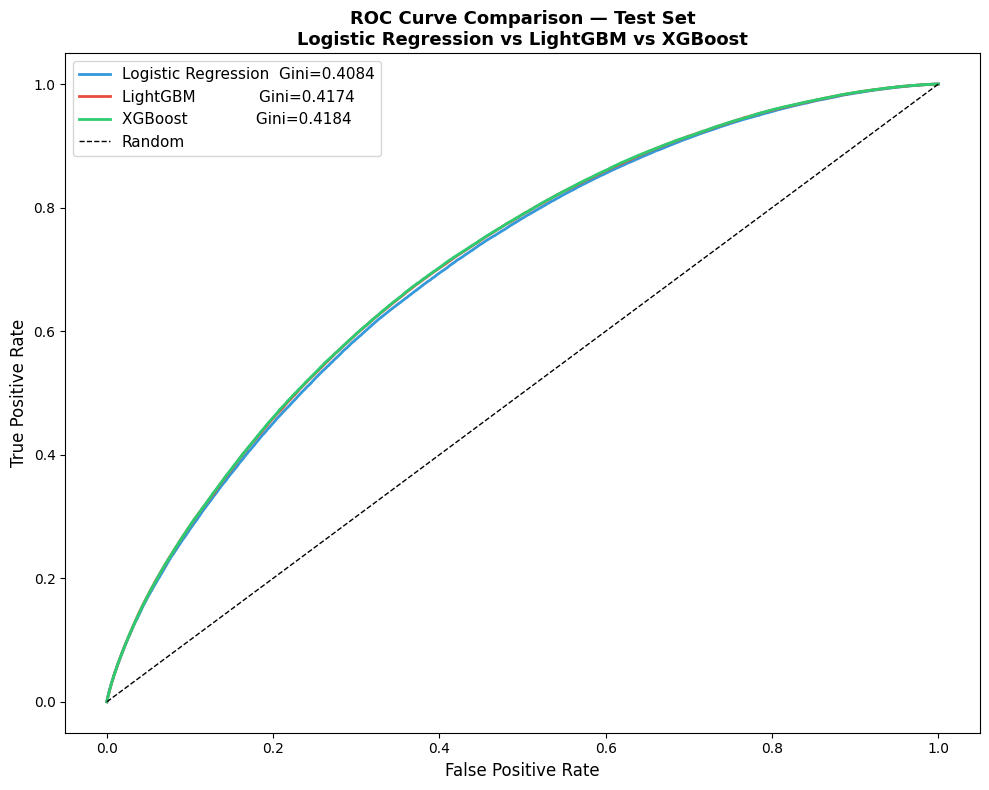

Saved: outputs/model_comparison_roc.png


In [7]:
# ROC curve — all three models on test set

fig, ax = plt.subplots(figsize=(10, 8))

fpr_lr,  tpr_lr,  _ = roc_curve(y_test, test_probs)
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, lgb_test_probs)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_test_probs)

ax.plot(fpr_lr,  tpr_lr,  color="#3498db", linewidth=2,
        label=f"Logistic Regression  Gini={0.4084:.4f}")
ax.plot(fpr_lgb, tpr_lgb, color="#e74c3c", linewidth=2,
        label=f"LightGBM             Gini={lgb_test_gini:.4f}")
ax.plot(fpr_xgb, tpr_xgb, color="#2ecc71", linewidth=2,
        label=f"XGBoost              Gini={xgb_test_gini:.4f}")
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random")

ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate",  fontsize=12)
ax.set_title(
    "ROC Curve Comparison — Test Set\n"
    "Logistic Regression vs LightGBM vs XGBoost",
    fontsize=13, fontweight="bold"
)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig("../outputs/model_comparison_roc.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/model_comparison_roc.png")

In [8]:
# SHAP feature importance — XGBoost
# SHAP explains individual predictions, not just global feature importance

import shap

explainer    = shap.TreeExplainer(xgb_model)
shap_values  = explainer.shap_values(X_test.iloc[:5000])  # sample for speed

print(f"SHAP values shape: {shap_values.shape}")

# Global feature importance — mean absolute SHAP value
shap_importance = pd.DataFrame({
    "feature"         : feature_cols,
    "mean_abs_shap"   : np.abs(shap_values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

print()
print("Feature Importance (mean |SHAP value|):")
print(f"{'Rank':<6} {'Feature':<30} {'Mean |SHAP|':>12}")
print("─" * 52)
for i, row in shap_importance.iterrows():
    print(f"{i+1:<6} {row['feature']:<30} {row['mean_abs_shap']:>12.4f}")

SHAP values shape: (5000, 14)

Feature Importance (mean |SHAP value|):
Rank   Feature                         Mean |SHAP|
────────────────────────────────────────────────────
1      sub_grade                            0.4862
2      term                                 0.2336
3      fico_range_low                       0.1536
4      dti                                  0.1365
5      log_annual_inc                       0.1262
6      loan_amnt                            0.1002
7      home_ownership                       0.0842
8      mort_acc                             0.0682
9      revol_util                           0.0536
10     mths_since_recent_inq                0.0525
11     purpose                              0.0318
12     verification_status                  0.0316
13     inq_last_6mths                       0.0299
14     installment                          0.0292


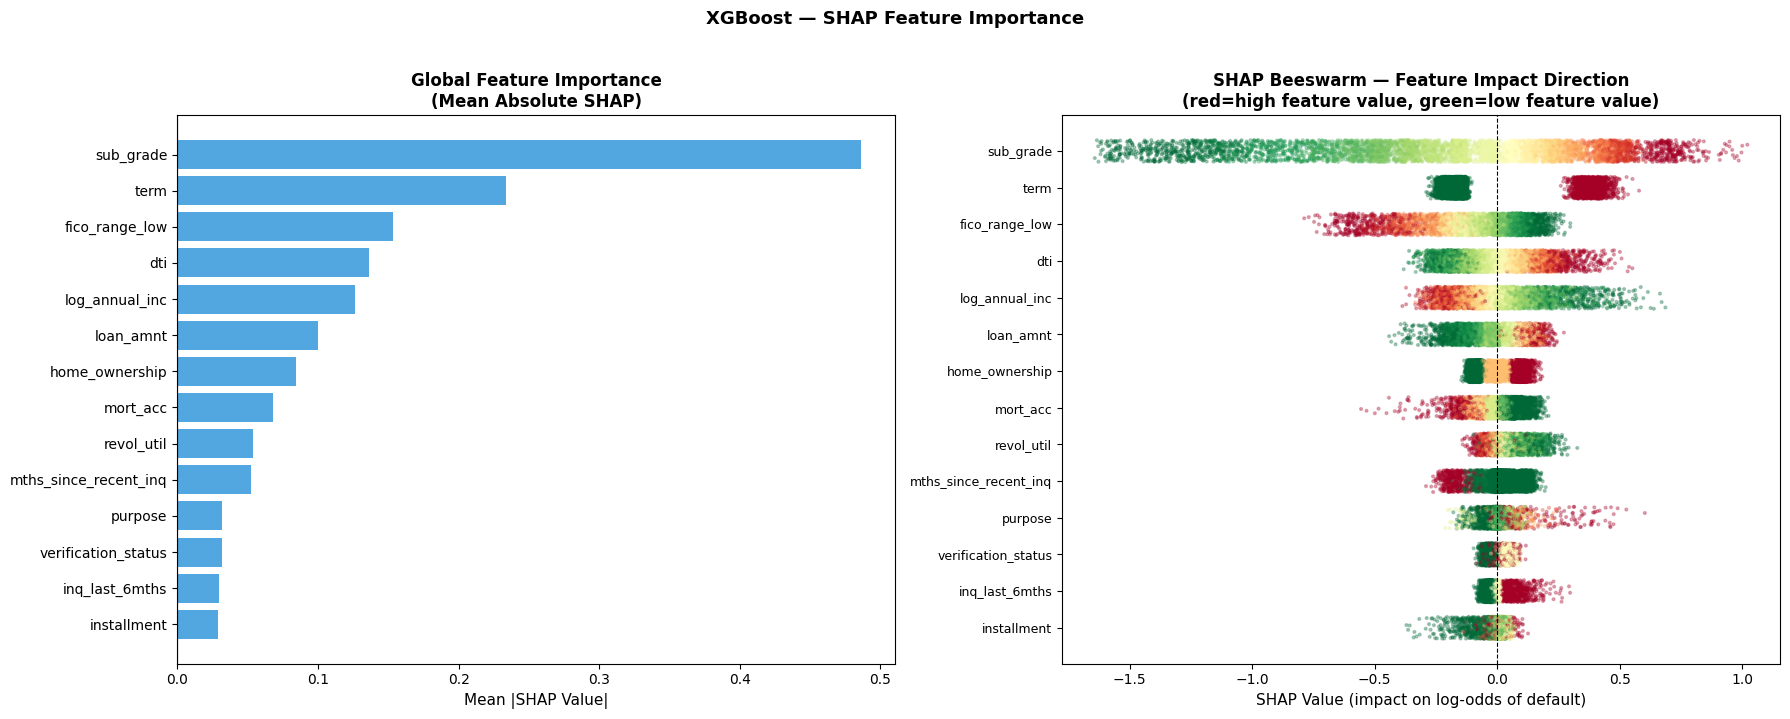

Saved: outputs/xgb_shap.png


In [9]:
# SHAP summary plot

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left — bar chart of mean absolute SHAP
axes[0].barh(
    shap_importance["feature"][::-1],
    shap_importance["mean_abs_shap"][::-1],
    color="#3498db", alpha=0.85
)
axes[0].set_xlabel("Mean |SHAP Value|", fontsize=11)
axes[0].set_title("Global Feature Importance\n(Mean Absolute SHAP)",
                   fontsize=12, fontweight="bold")
axes[0].axvline(x=0, color="black", linewidth=0.8)

# Right — SHAP beeswarm using matplotlib manually
# (avoids shap.summary_plot display issues in some environments)
shap_df = pd.DataFrame(shap_values, columns=feature_cols)

for i, feature in enumerate(shap_importance["feature"]):
    vals     = shap_df[feature].values
    feat_raw = X_test.iloc[:5000][feature]

    # Normalise feature values for colour
    if feat_raw.dtype.name == "category":
        colour_vals = feat_raw.cat.codes.values
    else:
        colour_vals = feat_raw.values

    norm = plt.Normalize(
        vmin=np.nanpercentile(colour_vals, 5),
        vmax=np.nanpercentile(colour_vals, 95)
    )
    colours = plt.cm.RdYlGn_r(norm(colour_vals))

    rank = shap_importance[shap_importance["feature"] == feature].index[0]
    y_jitter = np.random.uniform(-0.3, 0.3, size=len(vals))
    axes[1].scatter(
        vals,
        np.full(len(vals), 13 - rank) + y_jitter,
        c=colours, alpha=0.3, s=4
    )

axes[1].set_yticks(range(14))
axes[1].set_yticklabels(shap_importance["feature"][::-1], fontsize=9)
axes[1].axvline(x=0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_xlabel("SHAP Value (impact on log-odds of default)", fontsize=11)
axes[1].set_title("SHAP Beeswarm — Feature Impact Direction\n"
                   "(red=high feature value, green=low feature value)",
                   fontsize=12, fontweight="bold")

plt.suptitle("XGBoost — SHAP Feature Importance",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../outputs/xgb_shap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/xgb_shap.png")

In [10]:
# ECL comparison — LR vs XGBoost

df_raw_test   = pd.read_pickle("../data/processed/df_test.pkl")
ead           = df_raw_test["loan_amnt"].values
empirical_lgd = 0.6475

ecl_lr  = test_probs      * empirical_lgd * ead
ecl_xgb = xgb_test_probs  * empirical_lgd * ead
ecl_lgb = lgb_test_probs  * empirical_lgd * ead

actual_loss = ead[y_test == 1].sum() * empirical_lgd

print(f"ECL Comparison — Test Set")
print(f"{'Model':<25} {'Total ECL':>16} {'ECL/EAD':>10} {'ECL/Actual':>12}")
print("─" * 66)
for name, ecl in [
    ("Logistic Regression", ecl_lr),
    ("LightGBM",            ecl_lgb),
    ("XGBoost",             ecl_xgb),
]:
    print(f"{name:<25} ${ecl.sum():>14,.0f} "
          f"{ecl.sum()/ead.sum()*100:>9.2f}% "
          f"{ecl.sum()/actual_loss*100:>11.2f}%")

print()
print(f"Actual observed loss:     ${actual_loss:>14,.0f}")

ECL Comparison — Test Set
Model                            Total ECL    ECL/EAD   ECL/Actual
──────────────────────────────────────────────────────────────────
Logistic Regression       $   932,145,216     12.43%       79.03%
LightGBM                  $   975,932,397     13.01%       82.74%
XGBoost                   $   979,662,649     13.06%       83.06%

Actual observed loss:     $ 1,179,475,154


## Summary — Gradient Boosting Challengers and Model Comparison

---

### Models Trained

| Model | Best Iteration | Train Gini | Test Gini | Test KS | Gini Drop |
|-------|---------------|------------|-----------|---------|-----------|
| Logistic Regression | — | 0.4286 | 0.4084 | 0.2946 | 0.0202 |
| LightGBM | 246 | 0.4678 | 0.4174 | 0.3033 | 0.0504 |
| XGBoost | 315 | 0.4580 | 0.4184 | 0.3042 | 0.0396 |

---

### Key Finding

Gradient boosting improves test Gini by only +0.010 over logistic
regression. The ROC curves are visually indistinguishable. This is
the central result of the modelling exercise:

WoE encoding in Notebook 05 approximated the non-linear relationships
that tree models learn automatically. Once features are transformed
into log-odds space, logistic regression captures most of the available
signal. The remaining 0.010 Gini gain from gradient boosting does not
justify the loss of interpretability for a regulated credit scorecard.

**Champion model: Logistic Regression**
- Lowest Gini drop (0.020 vs 0.040-0.050 for boosting models)
- Fully interpretable scorecard with points per bin
- Regulatory preference for transparent, auditable models
- Comparable discrimination on held-out test set

**Best raw discrimination: XGBoost**
- Test Gini 0.4184 (+0.010 vs LR)
- Better ECL accuracy (83% of actual vs 79% for LR)
- Appropriate for internal risk monitoring where interpretability
  is less critical than accuracy

---

### SHAP Feature Importance (XGBoost)

| Rank | Feature | Mean |SHAP| |
|------|---------|-------------|
| 1 | sub_grade | 0.4862 |
| 2 | term | 0.2336 |
| 3 | fico_range_low | 0.1536 |
| 4 | dti | 0.1365 |
| 5 | log_annual_inc | 0.1262 |

SHAP ranking is consistent with IV ranking from Notebook 04 —
confirms feature selection was correct.

---

### ECL Comparison — Test Set ($7.50B EAD, LGD=64.75%)

| Model | Total ECL | ECL/EAD | vs Actual |
|-------|-----------|---------|-----------|
| Logistic Regression | $932M | 12.43% | 79.03% |
| LightGBM | $976M | 13.01% | 82.74% |
| XGBoost | $980M | 13.06% | 83.06% |
| Actual observed loss | $1,179M | 15.73% | 100% |

All models understate ECL due to population default rate shift
(train 18.46% → test 22.42%). Correctable via intercept
recalibration in production.


In [11]:
import pickle
import os

os.makedirs('../models', exist_ok=True)

# xgb_model — XGBClassifier (Cell 4)
with open('../models/xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

# lgb_model — LGBMClassifier (Cell 3)
with open('../models/lgb_model.pkl', 'wb') as f:
    pickle.dump(lgb_model, f)

# SHAP explainer fitted on xgb_model (Cell 8)
with open('../models/shap_explainer.pkl', 'wb') as f:
    pickle.dump(explainer, f)

# feature_cols — the 14 raw features used by both GBM models (Cell 1)
with open('../models/xgb_feature_cols.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)

print("Saved: xgb_model.pkl")
print("Saved: lgb_model.pkl")
print("Saved: shap_explainer.pkl")
print("Saved: xgb_feature_cols.pkl")

Saved: xgb_model.pkl
Saved: lgb_model.pkl
Saved: shap_explainer.pkl
Saved: xgb_feature_cols.pkl
